## Regressao Linear
### Introdução - Uma variável explicativa

Uma empresa está querendo verificar se a <b>remuneração</b> dos seus colaboradores está de acordo com as políticas vigentes. Para isso coletou uma amostra de 46 colaboradores conforme a seguir.

__Pergunta de Negócio__:
O salário muda de acordo com os anos de educação superior? Se sim, é possível construir um modelo que estime o salário de acordo com esses anos?

---

#### 01 - Importação das bibliotecas

In [ ]:
# Pacotes de manipulação de dados...
import numpy as np
import pandas as pd

# Pacotes gráficos...
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de modelagem...
import statsmodels.api as sm

#### 02 - Importação da base de dados

In [24]:
df = pd.read_csv('base_funcionarios_v1.csv', sep=';', index_col='id')

In [25]:
df.shape

(46, 2)

In [26]:
df.dtypes

Salario               float64
Anos_Educ_Superior      int64
dtype: object

#### 03 - Tabela de dados

In [27]:
df.head()

,Salario,Anos_Educ_Superior
id,,
1,5517.4,3
2,6399.9,4
3,6206.7,6
4,6060.6,4
5,6122.7,2


#### 04 - Análise exploratória dos dados

<Axes: xlabel='Anos_Educ_Superior', ylabel='Salario'>

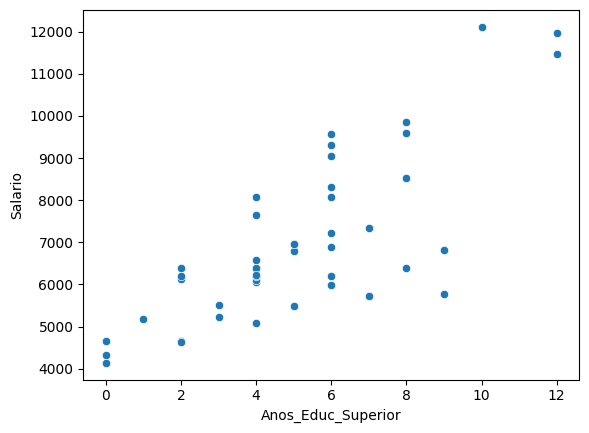

In [28]:
# Gráfico de dispersão...
sns.scatterplot(x=df['Anos_Educ_Superior'],
                y=df['Salario'])

<Axes: >

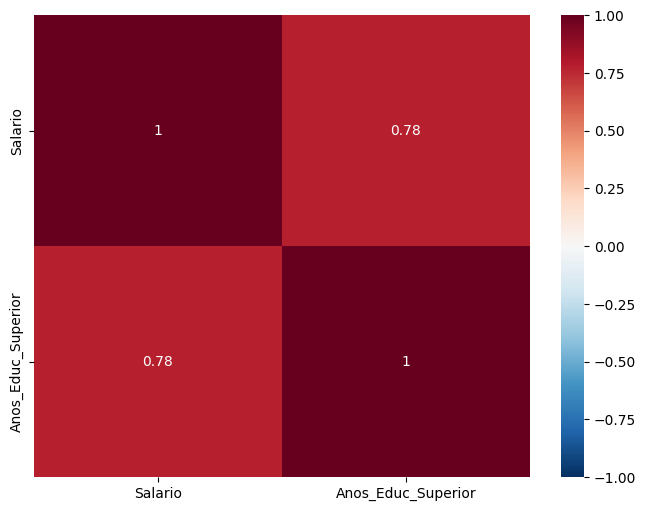

In [32]:
# Correlação linear de Pearson...
fig = plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            annot=True)

#### 05 - Criação do Modelo de Regressão usando a biblioteca Statsmodels

In [41]:
# Variável resposta...
y = df['Salario']

# Variável explicativa...
df['intercepto'] = 1 
x = df[['intercepto',
        'Anos_Educ_Superior']]
# y.shape
# y.head()
# x.shape
# x.head()

In [46]:
# Ajuste do modelo... 
# Convenção em regressão linear simples com intercepto:
# β₀ = intercepto (termo constante, ponto em que a reta cruza o eixo y) -> valor de intercepto ...
# β₁ = coeficiente angular (inclinação por unidade de x) -> valor do slope para Anos_Educ_Superior (onde y = β₀ + β₁·x) ...
# Resumo: β₀=constante e β₁=inclinação ...
modelo = sm.OLS(y,x)  # ajustar para o melhor beta 0 e beta 1...
resultado = modelo.fit()

In [47]:
# Resultado do ajuste...
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     67.03
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.18e-10
Time:                        22:06:33   Log-Likelihood:                -391.36
No. Observations:                  46   AIC:                             786.7
Df Residuals:                      44   BIC:                             790.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercepto          4301.7990    372

<Axes: xlabel='Anos_Educ_Superior', ylabel='Salario'>

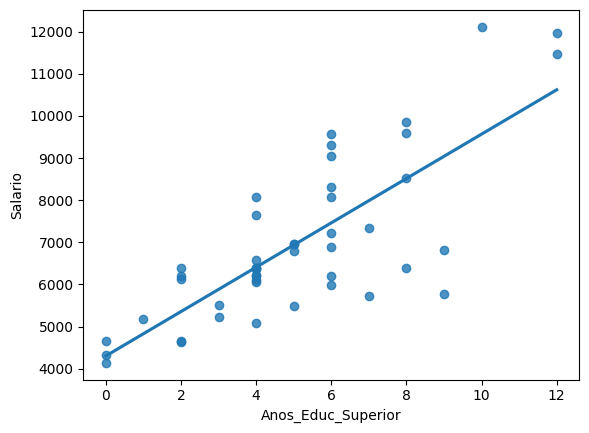

In [48]:
# Gráfico de dispersão com a reta de regressão linear...
sns.regplot(x=df['Anos_Educ_Superior'],
            y=df['Salario'],
            ci=None)

#### 06 - Interpretação dos Coeficientes

**Intercepto ou $\beta_0$**: Salário médio de um colaborador sem educação superior é de `R$4.301,80`.<br>
**$\beta_1$** x Anos de Educação Superior: Cada ano adicional de educação superior gera um aumento médio de `R$526,73`.<br>

#### 07 - Conclusão

modelo (funcao) explicativo 

resumo explicativo